# Bitcoin Statistical Inference — HAC Diebold–Mariano and Holm Correction

## Role
This notebook is the authoritative source for pairwise statistical claims about Bitcoin point-forecast accuracy.

## Inputs
The frozen final Bitcoin point forecasts (`results/validated_forecasts.csv`), the final ten-model roster, and the corrected pairwise inference artifact `results/bitcoin_dm_pairwise_results_hac_holm.csv`.

## Outputs
45 pairwise comparisons, HAC-adjusted DM statistics, raw p-values, Holm-adjusted p-values, raw and family-wise significance flags, and practical RMSE-difference evidence.

## Depends On
`07_Bitcoin_Forecast_Freeze_and_Validation.ipynb` and, conceptually, `08_Bitcoin_Naive_Audit.ipynb`.

## Authoritative Status
`AUTHORITATIVE BITCOIN STATISTICAL INFERENCE`

## What This Notebook Does Not Do
No model training. No forecast generation. No robustness scoring. No uncertainty calibration. No Trust Score synthesis. No cross-domain inference.

# 1. Objective and Research Question

> Of the 45 pairwise accuracy differences among the ten final Bitcoin forecasting models, which differences remain statistically distinguishable from chance after using autocorrelation-robust standard errors and family-wise multiple-comparison correction?

> **This HAC/Newey–West + Holm analysis is the authoritative source for Bitcoin significance claims. The earlier non-HAC DM artifact is retained for provenance only and must not be used for current inferential conclusions.**

Forecast-error loss series are time-ordered and may be serially dependent -- an independence-assuming variance estimator can distort inferential uncertainty. Testing 45 pairs also creates a multiple-comparison problem: testing each at 5% without adjustment increases the probability of at least one false rejection well above 5%. Raw p-values alone are therefore not sufficient for this project's final significance claims.

# 2. Setup

Standard project-root discovery. Only the frozen point-forecast matrix, the corrected HAC/Holm inference artifact, and lightweight pandas/NumPy verification utilities are loaded -- no forecasting model is rerun. The 45-pair artifact already exists and is protected; this notebook loads and validates it rather than regenerating it.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.bitcoin_pipeline import *

RUN_GENERATION = False
PROMOTE_TO_AUTHORITATIVE = False

# 3. Data and Method

## 3.1 Pairwise Forecast Comparison

For each pair of models A and B: `d_t = L(e_A,t) - L(e_B,t)`, where the current primary loss is squared error, `L(e) = e^2` (verified from `src.bitcoin_pipeline.hac_dm`: `differential = (a - fa)**2 - (a - fb)**2`).

Sign convention (verified from the same implementation, not assumed): a **negative** mean differential means Model A's squared loss was lower on average, i.e. it favours **Model A**; a **positive** mean differential favours **Model B**.

Null hypothesis: `H0: E[d_t] = 0` -- equal expected predictive loss between the two models.

## 3.2 Why HAC / Newey–West Variance

> Daily forecast-loss differentials are time-ordered and can exhibit serial dependence. A variance estimator that assumes independent loss observations may understate or distort inferential uncertainty.

The current analysis therefore uses a Heteroskedasticity-and-Autocorrelation-Consistent (HAC / Newey–West) long-run variance estimate with a Bartlett kernel (verified from `src.bitcoin_pipeline.hac_dm`).

The HAC lag is **derived from sample size**, not fixed by hand: `lag = floor(4 * (N/100)^(2/9))`, which gives **lag 6** at N=1,061 (verified live below, not assumed). The HAC correction changes the estimated standard error, the DM statistic, and the resulting p-value -- it does not alter the point forecasts themselves in any way.

## 3.3 Holm Family-Wise Error Correction

With 10 models, `C(10,2) = 45` pairwise hypotheses are tested. Testing each at 5% without adjustment increases the probability of at least one false rejection well above the nominal 5% level across the full family.

This notebook uses **Holm's step-down family-wise error rate correction** across the complete 45-test family, at `alpha = 0.05` (verified from the artifact's own `Significant Holm?` threshold below).

> **Holm-adjusted significance is the primary inferential conclusion throughout this project. Raw p-values are retained as descriptive secondary evidence only.**

A pair being "raw significant" does **not** automatically make it "final significant" -- final significance requires the Holm-adjusted p-value to fall below alpha.

## 3.4 Superseded Statistical Artifact

`results/bitcoin_dm_pairwise_results.csv` used an earlier, non-HAC variance methodology and an older model-naming/roster convention (e.g. "Persistence-Enhanced LSTM" and "Holt-Winters Rolling One-Step" rather than the current display names). It is retained for historical provenance only and **must not** be used for current significance claims. `results/bitcoin_dm_pairwise_results_hac_holm.csv` is the authoritative replacement. Neither file is deleted or modified by this notebook.

In [2]:
artifact_status = pd.DataFrame([
    {'Artifact': 'results/bitcoin_dm_pairwise_results.csv', 'Status': 'SUPERSEDED', 'Current Use': 'Provenance only'},
    {'Artifact': 'results/bitcoin_dm_pairwise_results_hac_holm.csv', 'Status': 'AUTHORITATIVE', 'Current Use': 'Current inference'},
]).set_index('Artifact')
artifact_status

,Status,Current Use
Artifact,,
results/bitcoin_dm_pairwise_results.csv,SUPERSEDED,Provenance only
results/bitcoin_dm_pairwise_results_hac_holm.csv,AUTHORITATIVE,Current inference


## 3.5 Interpretation Rules

**Statistical significance (primary)**: Holm-adjusted p-value < 0.05.
**Raw p-value**: secondary/descriptive only -- never the final conclusion on its own.
**Practical magnitude**: a statistically significant result is not automatically practically large, and vice versa. Every significance conclusion below is interpreted alongside absolute RMSE difference, relative RMSE difference, and the lower-RMSE model -- this notebook does not reduce to a binary significant/not-significant label.

# 4. Pairwise Statistical Results

## 4.1 Structural Validation

The checks below turn the artifact's structural assumptions into a visible, auditable PASS table before any inference is read from it.

In [3]:
dm = pd.read_csv(ROOT / 'results' / 'bitcoin_dm_pairwise_results_hac_holm.csv')

models_in_a = set(dm['Model A'])
models_in_b = set(dm['Model B'])
all_models = models_in_a | models_in_b
pair_keys = dm.apply(lambda r: frozenset({r['Model A'], r['Model B']}), axis=1)

structural_checks = pd.DataFrame([
    {'Validation Check': 'Models', 'Expected': 10, 'Observed': len(all_models), 'Result': 'PASS' if len(all_models) == 10 else 'FAIL'},
    {'Validation Check': 'Pairwise tests', 'Expected': 45, 'Observed': len(dm), 'Result': 'PASS' if len(dm) == 45 else 'FAIL'},
    {'Validation Check': 'Duplicate pairs', 'Expected': 0, 'Observed': int(pair_keys.duplicated().sum()), 'Result': 'PASS' if pair_keys.duplicated().sum() == 0 else 'FAIL'},
    {'Validation Check': 'Self comparisons', 'Expected': 0, 'Observed': int((dm['Model A'] == dm['Model B']).sum()), 'Result': 'PASS' if (dm['Model A'] == dm['Model B']).sum() == 0 else 'FAIL'},
    {'Validation Check': 'Missing raw p-values', 'Expected': 0, 'Observed': int(dm['Raw p-value'].isna().sum()), 'Result': 'PASS' if dm['Raw p-value'].isna().sum() == 0 else 'FAIL'},
    {'Validation Check': 'Missing Holm p-values', 'Expected': 0, 'Observed': int(dm['Holm-adjusted p-value'].isna().sum()), 'Result': 'PASS' if dm['Holm-adjusted p-value'].isna().sum() == 0 else 'FAIL'},
    {'Validation Check': 'Raw p-values in [0,1]', 'Expected': 45, 'Observed': int(dm['Raw p-value'].between(0, 1).sum()), 'Result': 'PASS' if dm['Raw p-value'].between(0, 1).all() else 'FAIL'},
    {'Validation Check': 'Holm p-values in [0,1]', 'Expected': 45, 'Observed': int(dm['Holm-adjusted p-value'].between(0, 1).sum()), 'Result': 'PASS' if dm['Holm-adjusted p-value'].between(0, 1).all() else 'FAIL'},
    {'Validation Check': 'HAC lag = 6 for all pairs', 'Expected': 45, 'Observed': int((dm['HAC Lag'] == 6).sum()), 'Result': 'PASS' if (dm['HAC Lag'] == 6).all() else 'FAIL'},
]).set_index('Validation Check')
assert (structural_checks['Result'] == 'PASS').all()
structural_checks

,Expected,Observed,Result
Validation Check,,,
Models,10,10,PASS
Pairwise tests,45,45,PASS
Duplicate pairs,0,0,PASS
Self comparisons,0,0,PASS
Missing raw p-values,0,0,PASS
Missing Holm p-values,0,0,PASS
"Raw p-values in [0,1]",45,45,PASS
"Holm p-values in [0,1]",45,45,PASS
HAC lag = 6 for all pairs,45,45,PASS


## 4.2 Full 45-Pair Statistical Table

Column meanings: **Model A / Model B** -- the compared pair; **Mean loss differential** -- mean squared-loss(A) minus squared-loss(B), sign convention per Section 3.1; **HAC DM statistic** -- the Newey–West-adjusted Diebold–Mariano statistic; **Raw p-value** -- unadjusted, descriptive only; **Holm-adjusted p-value** -- the primary inferential value; **Raw / Holm significance** -- boolean flags at alpha = 0.05; **Lower-RMSE model**, **Absolute / Relative RMSE difference** -- practical-magnitude evidence, independent of the significance flags.

All 45 pairs are shown, including non-significant ones -- they are part of the evidence, not omitted. Sorted by Holm-adjusted p-value ascending, then by absolute RMSE difference.

In [4]:
full_table = dm.sort_values(['Holm-adjusted p-value', 'Absolute RMSE difference'], ascending=[True, False])[[
    'Model A', 'Model B', 'Mean loss differential', 'DM statistic', 'Raw p-value',
    'Holm-adjusted p-value', 'Significant raw?', 'Significant Holm?',
    'Lower-RMSE model', 'Absolute RMSE difference', 'Relative RMSE difference',
]].reset_index(drop=True)
full_table

,Model A,Model B,Mean loss differential,DM statistic,Raw p-value,Holm-adjusted p-value,Significant raw?,Significant Holm?,Lower-RMSE model,Absolute RMSE difference,Relative RMSE difference
0,Persistence-Enhanced Log-Return LSTM,Persistence-Enhanced Log-Return Transformer,-3.013815e+06,-13.126894,2.309373e-39,1.039218e-37,True,True,Persistence-Enhanced Log-Return LSTM,678.658620,0.360779
1,Naive,Persistence-Enhanced Log-Return Transformer,-3.116394e+06,-12.305208,8.491742e-35,3.736366e-33,True,True,Naive,706.125036,0.380943
2,Simple Exponential Smoothing — Rolling One-Step,Persistence-Enhanced Log-Return Transformer,-3.108580e+06,-12.296315,9.480079e-35,4.076434e-33,True,True,Simple Exponential Smoothing — Rolling One-Step,704.018386,0.379375
3,ARIMA Rolling One-Step,Persistence-Enhanced Log-Return Transformer,-3.069233e+06,-11.870475,1.685076e-32,7.077317e-31,True,True,ARIMA Rolling One-Step,693.446951,0.371562
4,Additive-Trend Exponential Smoothing,Persistence-Enhanced Log-Return Transformer,-3.049050e+06,-11.845861,2.260837e-32,9.269432e-31,True,True,Additive-Trend Exponential Smoothing,688.047625,0.367605
5,Persistence-Enhanced Log-Return Transformer,TimesFM,2.849776e+06,11.272504,1.793933e-29,7.175733e-28,True,True,TimesFM,635.550473,0.330293
6,Naive,Prophet — 30-Day Periodic Refit,-1.127975e+08,-8.787771,1.525571e-18,5.918893e-17,True,True,Naive,8927.538099,4.816260
7,Simple Exponential Smoothing — Rolling One-Step,Prophet — 30-Day Periodic Refit,-1.127897e+08,-8.788354,1.517665e-18,5.918893e-17,True,True,Simple Exponential Smoothing — Rolling One-Step,8925.431449,4.809657
8,ARIMA Rolling One-Step,Prophet — 30-Day Periodic Refit,-1.127504e+08,-8.785321,1.559190e-18,5.918893e-17,True,True,ARIMA Rolling One-Step,8914.860014,4.776749
9,Additive-Trend Exponential Smoothing,Prophet — 30-Day Periodic Refit,-1.127302e+08,-8.784384,1.572243e-18,5.918893e-17,True,True,Additive-Trend Exponential Smoothing,8909.460688,4.760085


## 4.3 Practical Effect Size

The DM statistic and its p-value answer "is the loss difference statistically
detectable"; they do not by themselves say how large the difference is in a
distribution-free, unit-independent sense. This subsection adds a **paired standardized
absolute-error difference** for every one of the 45 pairs, computed from the same frozen
`Actual - Forecast` vectors used everywhere else in this notebook -- no forecast is
regenerated.

For pair `(A, B)`: `a_t = |e_A,t|`, `b_t = |e_B,t|`, `d_t = a_t - b_t`. The paired
standardized effect size is `d_paired = mean(d_t) / SD(d_t)` -- this is **not**
independent-samples Cohen's `d`; because `a_t` and `b_t` are paired observations on the
same date, this is the paired-difference statistic sometimes called **Cohen's `dz`**, and
it is labelled precisely as **Paired Standardized Absolute-Error Difference** throughout
this notebook rather than as a generic "Cohen's d". Sign convention: negative favours
Model A (A's absolute error is smaller on average), positive favours Model B -- the same
direction convention as the HAC DM statistic, but note the DM statistic uses *squared*
loss while this effect size uses *absolute* loss; the two need not agree exactly on
magnitude ranking even when they agree on direction.

Descriptive magnitude bands (conventional heuristics only, not a universal scientific
threshold, and not used to decide statistical significance):
`< 0.2` negligible, `0.2-0.5` small, `0.5-0.8` moderate, `> 0.8` large.

In [5]:
validated = load_validated_forecasts(ROOT)
_, target_nb11 = load_bitcoin_target(ROOT)
train_nb11, test_nb11 = canonical_split(target_nb11)
forecasts_nb11 = forecast_series(validated, target_nb11)
abs_errors_nb11 = {model: (validated.Actual - forecast).abs() for model, forecast in forecasts_nb11.items()}

def paired_effect_size(model_a, model_b):
    a = abs_errors_nb11[model_a].to_numpy(float)
    b = abs_errors_nb11[model_b].to_numpy(float)
    d = a - b
    mean_d = float(np.mean(d))
    sd_d = float(np.std(d, ddof=1))
    dz = mean_d / sd_d if sd_d > 0 else np.nan
    return mean_d, dz

def magnitude_label(value):
    magnitude = abs(value)
    if magnitude < 0.2:
        return "negligible"
    if magnitude < 0.5:
        return "small"
    if magnitude < 0.8:
        return "moderate"
    return "large"

effect_rows = []
for _, row in dm.iterrows():
    mean_abs_diff, dz = paired_effect_size(row["Model A"], row["Model B"])
    effect_rows.append({
        "Model A": row["Model A"], "Model B": row["Model B"],
        "Mean Absolute-Error Difference": mean_abs_diff,
        "Paired Standardized Absolute-Error Difference (dz)": dz,
        "Absolute Effect-Size Magnitude": magnitude_label(dz),
        "HAC DM statistic": row["DM statistic"], "Raw p-value": row["Raw p-value"],
        "Holm-adjusted p-value": row["Holm-adjusted p-value"],
        "Significant Holm?": row["Significant Holm?"],
        "Absolute RMSE difference": row["Absolute RMSE difference"],
        "Relative RMSE difference": row["Relative RMSE difference"],
    })
effect_sizes = pd.DataFrame(effect_rows)
effect_sizes_sorted = effect_sizes.sort_values("Holm-adjusted p-value").reset_index(drop=True)
effect_sizes_sorted

,Model A,Model B,Mean Absolute-Error Difference,Paired Standardized Absolute-Error Difference (dz),Absolute Effect-Size Magnitude,HAC DM statistic,Raw p-value,Holm-adjusted p-value,Significant Holm?,Absolute RMSE difference,Relative RMSE difference
0,Persistence-Enhanced Log-Return LSTM,Persistence-Enhanced Log-Return Transformer,-698.001031,-0.601380,moderate,-13.126894,2.309373e-39,1.039218e-37,True,678.658620,0.360779
1,Naive,Persistence-Enhanced Log-Return Transformer,-729.013100,-0.537457,moderate,-12.305208,8.491742e-35,3.736366e-33,True,706.125036,0.380943
2,Simple Exponential Smoothing — Rolling One-Step,Persistence-Enhanced Log-Return Transformer,-729.007658,-0.537251,moderate,-12.296315,9.480079e-35,4.076434e-33,True,704.018386,0.379375
3,ARIMA Rolling One-Step,Persistence-Enhanced Log-Return Transformer,-719.491704,-0.513717,moderate,-11.870475,1.685076e-32,7.077317e-31,True,693.446951,0.371562
4,Additive-Trend Exponential Smoothing,Persistence-Enhanced Log-Return Transformer,-710.825028,-0.506532,moderate,-11.845861,2.260837e-32,9.269432e-31,True,688.047625,0.367605
5,Persistence-Enhanced Log-Return Transformer,TimesFM,669.419556,0.477930,small,11.272504,1.793933e-29,7.175733e-28,True,635.550473,0.330293
6,Additive-Trend Exponential Smoothing,Prophet — 30-Day Periodic Refit,-6886.721548,-0.994706,large,-8.784384,1.572243e-18,5.918893e-17,True,8909.460688,4.760085
7,ARIMA Rolling One-Step,Prophet — 30-Day Periodic Refit,-6895.388224,-0.995606,large,-8.785321,1.559190e-18,5.918893e-17,True,8914.860014,4.776749
8,Simple Exponential Smoothing — Rolling One-Step,Prophet — 30-Day Periodic Refit,-6904.904178,-0.997986,large,-8.788354,1.517665e-18,5.918893e-17,True,8925.431449,4.809657
9,Prophet — 30-Day Periodic Refit,Persistence-Enhanced Log-Return LSTM,6873.897551,0.987566,large,8.778122,1.662272e-18,5.918893e-17,True,8900.071683,4.731335


This table does not change any HAC/Holm conclusion above -- `Significant Holm?` is
reproduced unchanged from the authoritative artifact, not recomputed. It adds a magnitude
lens alongside the existing significance and RMSE-difference evidence: a pair can be
Holm-significant with only a negligible-to-small paired effect size (common at N=1,061,
where even small, consistent differences are detectable), and conversely a pair with a
larger effect size is not automatically the more RMSE-different pair, since RMSE
(squared-loss-based) and this effect size (absolute-loss-based) can rank pairs
differently.

### Derived Artifact

In [6]:
# This is a new, notebook-owned DERIVED ANALYTICAL EVIDENCE file, not a protected
# artifact -- unlike every results/bitcoin_*.csv this notebook only reads, this one is
# safe to (re)write idempotently so Restart Kernel + Run All stays reproducible. It never
# touches results/bitcoin_dm_pairwise_results_hac_holm.csv (the authoritative artifact),
# which remains read-only throughout this notebook.
effects_path = ROOT / "results" / "bitcoin_dm_pairwise_results_hac_holm_effects.csv"
effect_sizes_sorted.to_csv(effects_path, index=False)
print("Derived analytical evidence written (does not alter any authoritative artifact):", effects_path)

Derived analytical evidence written (does not alter any authoritative artifact): E:\Re_Sc_AM\TimeSeriesFoundationModels\results\bitcoin_dm_pairwise_results_hac_holm_effects.csv


# 5. Holm Significance Structure

## 5.1 Holm Significance Matrix

`S` = statistically significant after Holm correction; `NS` = not significant after Holm correction; the diagonal (`—`) is the same model and is not tested. The matrix is conceptually symmetric (each pair implies the same conclusion in both directions) even though each unordered pair was tested once; both triangles are filled in for readability. **This matrix uses Holm-adjusted significance only** -- raw significance is not shown here (see Section 4.2 for raw values).

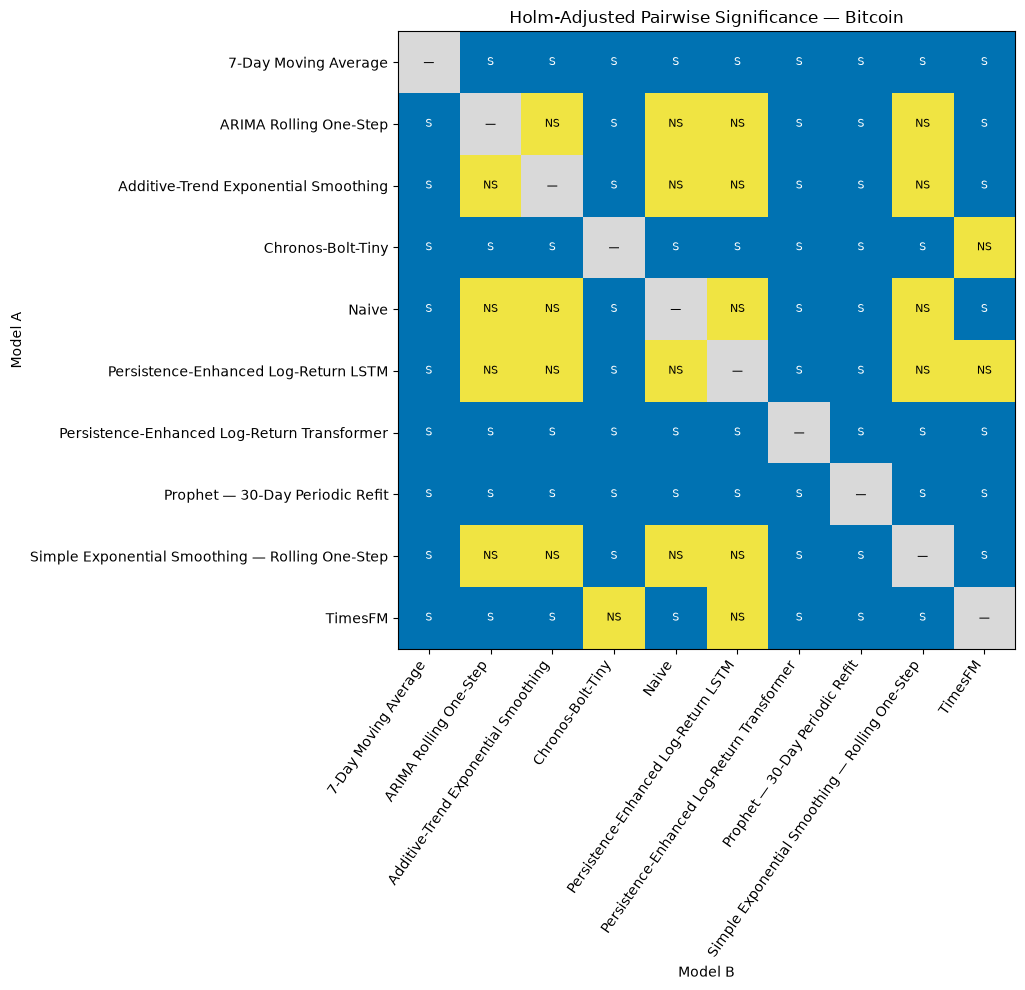

In [7]:
models = sorted(all_models)
holm = pd.DataFrame(np.nan, index=models, columns=models)
for model in models:
    holm.loc[model, model] = -1
for _, row in dm.iterrows():
    value = int(bool(row['Significant Holm?']))
    holm.loc[row['Model A'], row['Model B']] = value
    holm.loc[row['Model B'], row['Model A']] = value

fig, ax = plt.subplots(figsize=(11, 10))
ax.imshow(holm.to_numpy(), cmap=ListedColormap(['#D9D9D9', '#F0E442', '#0072B2']), vmin=-1, vmax=1)
ax.set_xticks(range(len(models)), models, rotation=55, ha='right')
ax.set_yticks(range(len(models)), models)
for i in range(len(models)):
    for j in range(len(models)):
        label = '—' if i == j else ('S' if holm.iloc[i, j] == 1 else 'NS')
        ax.text(j, i, label, ha='center', va='center', color='white' if holm.iloc[i, j] == 1 else 'black', fontsize=8)
ax.set(title='Holm-Adjusted Pairwise Significance — Bitcoin', xlabel='Model B', ylabel='Model A')
fig.tight_layout()
plt.show()

## 5.2 Significance Summary

Computed live from the authoritative artifact, not hard-coded.

In [8]:
significance_summary = pd.DataFrame([
    {'Significance Criterion': 'Raw p < 0.05', 'Significant Pairs': int(dm['Significant raw?'].sum()),
     'Non-Significant Pairs': int((~dm['Significant raw?']).sum()), 'Total': len(dm)},
    {'Significance Criterion': 'Holm-adjusted p < 0.05', 'Significant Pairs': int(dm['Significant Holm?'].sum()),
     'Non-Significant Pairs': int((~dm['Significant Holm?']).sum()), 'Total': len(dm)},
]).set_index('Significance Criterion')
significance_summary

,Significant Pairs,Non-Significant Pairs,Total
Significance Criterion,,,
Raw p < 0.05,39,6,45
Holm-adjusted p < 0.05,33,12,45


In [9]:
lost_to_correction = int((dm['Significant raw?'] & ~dm['Significant Holm?']).sum())
print(f'{lost_to_correction} pairs were significant under the raw p-value but lose significance after Holm correction.')

6 pairs were significant under the raw p-value but lose significance after Holm correction.


# 6. High-Value Pair Interpretations

These three pairs are inspected individually because they are the pairs most likely to be cited elsewhere in this repository. Not all are significant -- non-significant pairs are reported with equal precision.

In [10]:
def pair_row(a, b):
    row = dm[((dm['Model A'] == a) & (dm['Model B'] == b)) | ((dm['Model A'] == b) & (dm['Model B'] == a))]
    return row.iloc[0]

high_value_pairs = pd.DataFrame([
    pair_row('TimesFM', 'Chronos-Bolt-Tiny'),
    pair_row('Persistence-Enhanced Log-Return LSTM', 'TimesFM'),
    pair_row('Naive', 'ARIMA Rolling One-Step'),
])[[
    'Model A', 'Model B', 'Raw p-value', 'Significant raw?', 'Holm-adjusted p-value', 'Significant Holm?',
    'Lower-RMSE model', 'Absolute RMSE difference', 'Relative RMSE difference',
]].reset_index(drop=True)
high_value_pairs

,Model A,Model B,Raw p-value,Significant raw?,Holm-adjusted p-value,Significant Holm?,Lower-RMSE model,Absolute RMSE difference,Relative RMSE difference
0,Chronos-Bolt-Tiny,TimesFM,0.011020,True,0.121222,False,TimesFM,69.808589,0.036279
1,Persistence-Enhanced Log-Return LSTM,TimesFM,0.034524,True,0.293475,False,Persistence-Enhanced Log-Return LSTM,43.108147,0.022917
2,Naive,ARIMA Rolling One-Step,0.252014,False,1.000000,False,Naive,12.678085,0.006840


### TimesFM vs Chronos-Bolt-Tiny

TimesFM has the lower RMSE. Raw p-value 0.0110 (**significant raw**); Holm-adjusted p-value 0.1212 (**not significant**). Absolute RMSE difference 69.81 (relative 3.63%). **Authoritative conclusion: not statistically significant under Holm correction**, despite the raw p-value being below 0.05. This pair is worth special attention because downstream project documentation has, at points, described this comparison as "significant" using only the raw p-value; the Holm-adjusted conclusion above is the one this project treats as authoritative.

### Persistence-Enhanced Log-Return LSTM vs TimesFM

PE-LSTM has the lower RMSE. Raw p-value 0.0345 (**significant raw**); Holm-adjusted p-value 0.2935 (**not significant**). Absolute RMSE difference 43.11 (relative 2.29%). **Authoritative conclusion: not statistically significant under Holm correction.**

### Naive vs ARIMA Rolling One-Step

Naive has the lower RMSE. Raw p-value 0.2520 (**not significant even before correction**); Holm-adjusted p-value 1.0000 (**not significant**). Absolute RMSE difference 12.68 (relative 0.68%) -- a practically small gap that is also not statistically detectable at either stage. **Authoritative conclusion: no statistically significant difference, at any stage of correction.**

# 7. Key Findings

### Overall family result

Of the 45 total pairwise comparisons among the ten final Bitcoin models, 39 are significant under the raw p-value and 33 remain significant after Holm correction -- **6 pairs that appeared significant under the raw p-value do not survive family-wise correction.**

### Important pair conclusions (Holm-adjusted, authoritative)

- **TimesFM vs Chronos-Bolt-Tiny: not significant** (Holm p = 0.1212), despite raw significance (p = 0.0110).
- **Persistence-Enhanced Log-Return LSTM vs TimesFM: not significant** (Holm p = 0.2935), despite raw significance (p = 0.0345).
- **Naive vs ARIMA Rolling One-Step: not significant** (Holm p = 1.0000; not significant even under the raw p-value).

### Statistical vs practical importance

> A statistically detectable difference can still be practically small, while a numerically visible RMSE difference can fail to reach significance after serial-dependence and multiplicity adjustment.

Notebook 07 answers "who ranks where" -- it establishes the authoritative full ten-model RMSE ranking and is not redefined here. Notebook 11 answers a different question: "which of those ranking differences are statistically distinguishable from chance." A model can rank strictly ahead of another in Notebook 07 while this notebook finds no statistically significant difference between them (as with all three pairs above) -- the two notebooks are complementary, not redundant.

# 8. Limitations

### Loss Function Choice
The primary DM analysis uses squared-error loss. Other defensible loss functions (e.g. absolute-error loss) may yield different inferential conclusions. No comprehensive loss-function sensitivity analysis exists in this repository.

### HAC Lag Choice
HAC inference depends on the chosen lag/bandwidth. The lag used here is derived from a standard sample-size-based rule (`floor(4*(N/100)^(2/9))` = 6), not tuned or searched; no lag-sensitivity analysis exists in this repository.

### Pairwise Nature
DM tests are pairwise and do not constitute one global model-ranking test -- 45 separate hypotheses are tested, not one omnibus test of "are all ten models equal."

### Multiple-Testing Method
Holm controls family-wise error and is conservative by design.

> Bitcoin and Electricity currently use different multiple-testing corrections (Bitcoin: Holm; Electricity: Benjamini–Hochberg), so cross-domain significance counts should not be compared as if generated under an identical inferential procedure.

This is a cross-domain methodological limitation; Electricity's methodology is not modified here.

### Finite Test Period
Inference applies to this Bitcoin asset, this frozen 1,061-target period, and this one-step forecasting protocol only.

### Forecast Loss Dependence
HAC mitigates serial dependence in loss differentials but does not guarantee that every complex dependence structure in the underlying series is perfectly modelled.

# 9. Next Notebook

Next: `12_Bitcoin_Trustworthiness_Synthesis.ipynb`

Notebook 12 synthesises the already-separated evidence dimensions -- aggregate point accuracy, Regime-Conditional Robustness, Temporal Stability, Uncertainty Calibration, Transparency and Auditability, and statistical/practical evidence -- into a dimension-first trustworthiness summary. Notebook 12 should consume the authoritative HAC/Holm conclusions established here, not the superseded non-HAC DM file.